# NB01: SPARC Baseline Reproduction

**Paper 3 Gate Check** -- Reproduce the Paper 2 g(Rt) result from existing RT fits.

**Expected outcome:**
- N = 98 spatially resolved galaxies (Rt < R_max)
- Median g(Rt) = 6.51 x 10^-11 m/s^2 (8.3% above a0/2)
- Raw scatter = 0.409 dex (half 16th-84th percentile range)

If this notebook does not reproduce these values, **stop and diagnose before proceeding.**

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is on path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.fit import run_phase1_baseline
from src.physics import A0_HALF, ACCEL_TO_MKS

a0_half_mks = A0_HALF * ACCEL_TO_MKS  # 6.00e-11 m/s^2

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

## 1. Run Baseline Reproduction

In [2]:
baseline_df = run_phase1_baseline()

n_resolved = len(baseline_df)
median_g = baseline_df["g_Rt_mks"].median()
ratio = median_g / a0_half_mks
offset_pct = (ratio - 1) * 100

print(f"\nResolved galaxies: {n_resolved}")
print(f"Median g(Rt):      {median_g:.4e} m/s^2")
print(f"a0/2:              {a0_half_mks:.4e} m/s^2")
print(f"Ratio:             {ratio:.4f}")
print(f"Offset:            {offset_pct:+.1f}%")


  Phase 1: SPARC Baseline Reproduction
  Resolved galaxies (Rt < R_max): 98
  Median g(Rt): 6.5122e-11 m/s^2
  a0/2:         6.0003e-11 m/s^2
  Ratio:        1.0853
  Offset:       +8.5%

  BASELINE REPRODUCED: matches Paper 2 (N=98, ~8.3% offset)

Resolved galaxies: 98
Median g(Rt):      6.5122e-11 m/s^2
a0/2:              6.0003e-11 m/s^2
Ratio:             1.0853
Offset:            +8.5%


## 2. g(Rt) Distribution

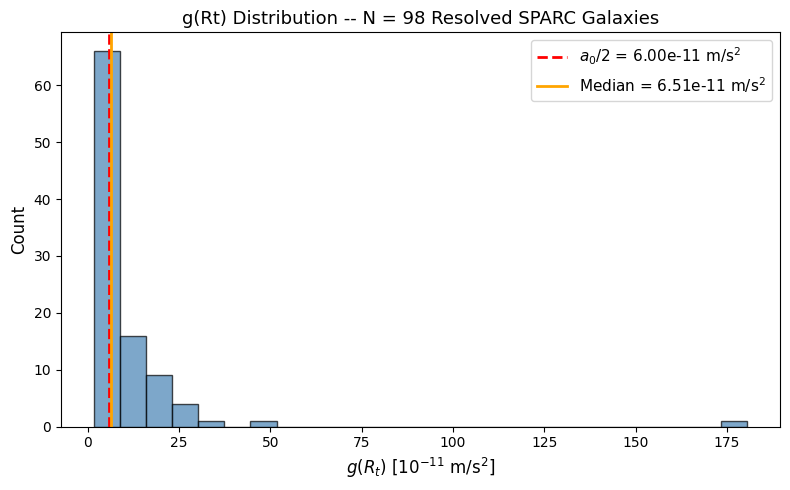

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

g_values = baseline_df["g_Rt_mks"].values * 1e11  # scale for readability
ax.hist(g_values, bins=25, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(a0_half_mks * 1e11, color="red", linestyle="--", linewidth=2,
           label=f"$a_0/2$ = {a0_half_mks:.2e} m/s$^2$")
ax.axvline(median_g * 1e11, color="orange", linestyle="-", linewidth=2,
           label=f"Median = {median_g:.2e} m/s$^2$")

ax.set_xlabel(r"$g(R_t)$ [$10^{-11}$ m/s$^2$]", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"g(Rt) Distribution -- N = {n_resolved} Resolved SPARC Galaxies", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(results_dir / "NB01_g_Rt_histogram.png", dpi=150)
plt.show()

## 3. g(Rt) vs Rt Scatter

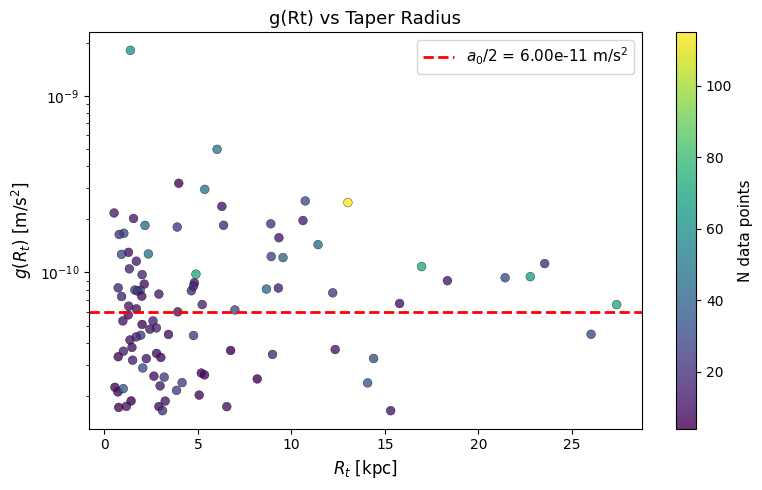

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(baseline_df["Rt"], baseline_df["g_Rt_mks"],
                c=baseline_df["n_points"], cmap="viridis", edgecolors="k",
                linewidth=0.3, s=40, alpha=0.8)
ax.axhline(a0_half_mks, color="red", linestyle="--", linewidth=2,
           label=f"$a_0/2$ = {a0_half_mks:.2e} m/s$^2$")

ax.set_xlabel("$R_t$ [kpc]", fontsize=12)
ax.set_ylabel("$g(R_t)$ [m/s$^2$]", fontsize=12)
ax.set_yscale("log")
ax.set_title("g(Rt) vs Taper Radius", fontsize=13)
ax.legend(fontsize=11)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("N data points", fontsize=11)
plt.tight_layout()
plt.savefig(results_dir / "NB01_g_Rt_vs_Rt.png", dpi=150)
plt.show()

## 4. Rt / R_max Distribution

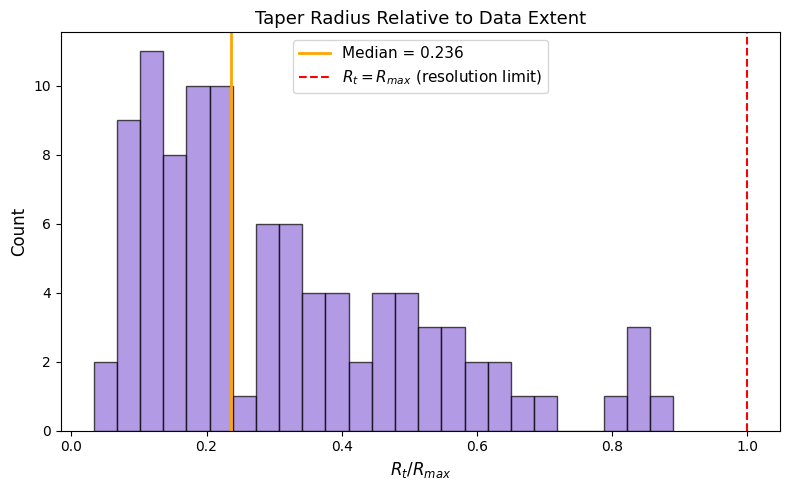

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

rt_ratio = baseline_df["Rt_over_Rmax"].values
median_ratio = np.median(rt_ratio)

ax.hist(rt_ratio, bins=25, edgecolor="black", alpha=0.7, color="mediumpurple")
ax.axvline(median_ratio, color="orange", linestyle="-", linewidth=2,
           label=f"Median = {median_ratio:.3f}")
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5,
           label="$R_t = R_{{max}}$ (resolution limit)")

ax.set_xlabel("$R_t / R_{max}$", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Taper Radius Relative to Data Extent", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(results_dir / "NB01_Rt_over_Rmax.png", dpi=150)
plt.show()

## 5. Summary Statistics

In [6]:
log_g = np.log10(baseline_df["g_Rt_mks"].values)
p16, p50, p84 = np.percentile(log_g, [16, 50, 84])
scatter_raw = (p84 - p16) / 2.0

print("Summary Statistics (resolved SPARC sample)")
print("=" * 50)
print(f"  N resolved:           {n_resolved}")
print(f"  Median g(Rt):         {10**p50:.4e} m/s^2")
print(f"  Mean g(Rt):           {baseline_df['g_Rt_mks'].mean():.4e} m/s^2")
print(f"  16th percentile:      {10**p16:.4e} m/s^2")
print(f"  84th percentile:      {10**p84:.4e} m/s^2")
print(f"  Raw scatter (dex):    {scatter_raw:.3f}")
print(f"  Median Rt/R_max:      {median_ratio:.3f}")
print(f"  Median Rt:            {baseline_df['Rt'].median():.2f} kpc")

Summary Statistics (resolved SPARC sample)
  N resolved:           98
  Median g(Rt):         6.5118e-11 m/s^2
  Mean g(Rt):           1.0384e-10 m/s^2
  16th percentile:      2.4408e-11 m/s^2
  84th percentile:      1.6046e-10 m/s^2
  Raw scatter (dex):    0.409
  Median Rt/R_max:      0.236
  Median Rt:            3.15 kpc


## 6. Gate Check

In [7]:
checks = {
    "N = 98": n_resolved == 98,
    "Median g(Rt) within 1% of 6.51e-11": abs(median_g / 6.51e-11 - 1) < 0.01,
    "Offset within [7%, 10%] of a0/2": 7.0 < offset_pct < 10.0,
    "Raw scatter within 5% of 0.409 dex": abs(scatter_raw / 0.409 - 1) < 0.05,
}

print("GATE CHECK: SPARC Baseline Reproduction")
print("=" * 50)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> BASELINE REPRODUCED -- safe to proceed to NB02 <<<")
else:
    print("  >>> BASELINE FAILED -- diagnose before continuing <<<")

baseline_df.to_csv(results_dir / "NB01_baseline_results.csv", index=False)

GATE CHECK: SPARC Baseline Reproduction
  [PASS] N = 98
  [PASS] Median g(Rt) within 1% of 6.51e-11
  [PASS] Offset within [7%, 10%] of a0/2
  [PASS] Raw scatter within 5% of 0.409 dex

  >>> BASELINE REPRODUCED -- safe to proceed to NB02 <<<
